# Confronto fra Quicksort e Counting Sort

---

## Introduzione

## Quicksort

### Descrizione


### Complessità


### Algoritmo

In [1]:
def partition(seq, start, stop):
    pivotIndex = start
    pivot = seq[pivotIndex]
    i = start + 1
    j = stop - 1

    while i <= j:
        while i <= j and seq[i] <= pivot:
            i += 1
        while i <= j and pivot < seq[j]:
            j -= 1

        if i < j:
            tmp = seq[i]
            seq[i] = seq[j]
            seq[j] = tmp
            i += 1
            j -= 1

    seq[pivotIndex] = seq[j]
    seq[j] = pivot

    return j

In [2]:
def quicksort(seq, start, stop):
    if start >= stop - 1:
        return

    pivotIndex = partition(seq, start, stop)

    quicksort(seq, start, pivotIndex)
    quicksort(seq, pivotIndex + 1, stop)

### Esempio di Utilizzo

In [3]:
seq = [23, 61, 93, 84, 16, 56, 46, 2, 55, 95]
quicksort(seq, 0, len(seq)-1)
print('La lista ordinata è: ', seq)

La lista ordinata è:  [2, 16, 23, 46, 55, 56, 61, 84, 93, 95]


## Counting Sort

### Descrizione

### Complessità

### Algoritmo


In [4]:
def counting_sort(seq):
    n = len(seq)
    maxval = max(seq)

    # create and initialize cntArr
    countSeq = [0] * (maxval + 1)

    # count frequency of each element
    for v in seq:
        countSeq[v] += 1

    # compute prefix sums
    for i in range(1, maxval + 1):
        countSeq[i] += countSeq[i - 1]

    # build output array
    ans = [0] * n
    
    # iterate in reverse to keep it stable
    for i in range(n - 1, -1, -1):
        v = seq[i]
        ans[countSeq[v] - 1] = v
        countSeq[v] -= 1

    return ans

### Esempio di Utilizzo

In [5]:
seq = [43, 35, 16, 87, 74, 45, 100, 64, 50, 30]
ordered_list = counting_sort(seq)
print('La lista ordinata è: ', ordered_list)



La lista ordinata è:  [16, 30, 35, 43, 45, 50, 64, 74, 87, 100]


In [6]:
#TODO aggiungere un test che dimsotri che l'algoritmo sia stabile

---

## Esperimento

1. Test su lista casuale
2. Test su lista già ordinata
3. Test su lista ordinata al contrario
4. Test su lista molti elementi ma range ristretto

[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]


ValueError: x and y must have same first dimension, but have shapes (10,) and (20,)

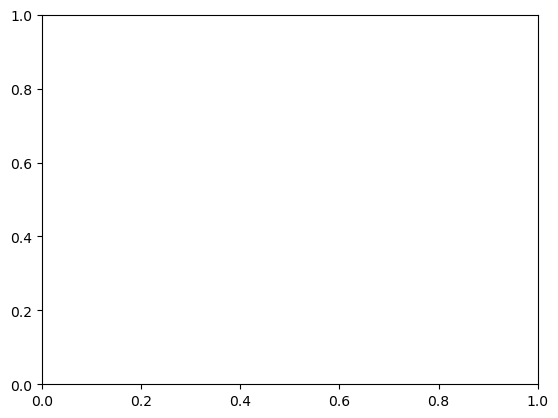

In [8]:
import random
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.setrecursionlimit(10 ** 9)

# Creo la lista completamente randomizzata su un range molto ampio
def randomList(size):
    return random.sample(range(1, size * 10), size)

# Creo la lista ordinata in modo crescente
def orderedList(size):
    return list(range(size))

# Creo la lista ordinata in modo decrescente
def invertedOrderedList(size):
     return list(range(size - 1, -1, -1))

# Creo una lista di grande dimensione ma con range ristretto e valori ripetuti
def smallRangeList(size):
    return random.choices(range(1, 101), k=size)

def experiment(seq_type, size, iterations):
    time_quicksort = []
    time_counting_sort = []
    size_sampling = []

    

    
    for i in range(iterations):
        size_sampling.append(size * (i + 1))
        
        # Comincio il test per il quicksort
        tmp = seq_type #Quicksort è in place quindi effettuo una copia
        start = timer()
        quicksort(tmp, 0, len(seq_type) -1)
        end = timer()
        time_quicksort.append(end - start)

        # Comincio il test per il counting sort
        start = timer()
        counting_sort(seq_type) #Non occorre fare una copia della lista per il counting sort
        end = timer()
        time_quicksort.append(end - start)

    print(size_sampling)
    
    plt.plot(size_sampling, time_quicksort, label='Quicksort')
    plt.plot(size_sampling, time_counting_sort, label='Counting Sort')
    plt.xlabel('Numero di elementi nella lista')
    plt.ylabel('Tempo di esecuzione in secondi')
    plt.title()
    plt.legend()
    plt.show()



experiment(randomList(100*10), 100, 10)

## Conclusioni

## Bibliografia e Sitografia

- [Generate a random list in python - GeeksforGeeks](https://www.geeksforgeeks.org/python/generating-random-number-list-in-python/)
- [Counting sort - Wikipedia](https://en.wikipedia.org/wiki/Counting_sort) <br>
- [Counting sort - GeeksforGeeks](https://www.geeksforgeeks.org/dsa/counting-sort/)